In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
data=pd.read_csv('spam_ham.csv', encoding='latin', usecols=[0,1])

In [3]:
data=pd.read_csv('spam_ham.csv', encoding='latin', usecols=[0,1])
data.rename({'v1':'label', 'v2':'message'}, axis=1, inplace=True)

In [4]:
data

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [5]:
data['message']

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                Will Ì_ b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: message, Length: 5572, dtype: object

In [6]:
corpus=data['message'].values
corpus

array(['Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...',
       'Ok lar... Joking wif u oni...',
       "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's",
       ..., 'Pity, * was in mood for that. So...any other suggestions?',
       "The guy did some bitching but I acted like i'd be interested in buying something else next week and he gave it to us for free",
       'Rofl. Its true to its name'], dtype=object)

### Removing Stop Words

In [7]:
import nltk

In [8]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [9]:
from nltk.corpus import stopwords

In [10]:
stopword=stopwords.words('english')
stopword

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [11]:
def process_text(corpus): 
    i=0
    while i<len(corpus): 
        msg=corpus[i].lower()
        sentance=[]
        for word in msg.split(): 
            if word not in stopword: 
                sentance.append(word)
        msg=" ".join(sentance)
        corpus[i]=msg
        i+=1 
    return " ".join(corpus)

In [12]:
s=process_text(corpus)
s

'go jurong point, crazy.. available bugis n great world la e buffet... cine got amore wat... ok lar... joking wif u oni... free entry 2 wkly comp win fa cup final tkts 21st may 2005. text fa 87121 receive entry question(std txt rate)t&c\'s apply 08452810075over18\'s u dun say early hor... u c already say... nah think goes usf, lives around though freemsg hey darling 3 week\'s word back! like fun still? tb ok! xxx std chgs send, å£1.50 rcv even brother like speak me. treat like aids patent. per request \'melle melle (oru minnaminunginte nurungu vettam)\' set callertune callers. press *9 copy friends callertune winner!! valued network customer selected receivea å£900 prize reward! claim call 09061701461. claim code kl341. valid 12 hours only. mobile 11 months more? u r entitled update latest colour mobiles camera free! call mobile update co free 08002986030 gonna home soon want talk stuff anymore tonight, k? cried enough today. six chances win cash! 100 20,000 pounds txt> csh11 send 8757

In [13]:
s.split()

['go',
 'jurong',
 'point,',
 'crazy..',
 'available',
 'bugis',
 'n',
 'great',
 'world',
 'la',
 'e',
 'buffet...',
 'cine',
 'got',
 'amore',
 'wat...',
 'ok',
 'lar...',
 'joking',
 'wif',
 'u',
 'oni...',
 'free',
 'entry',
 '2',
 'wkly',
 'comp',
 'win',
 'fa',
 'cup',
 'final',
 'tkts',
 '21st',
 'may',
 '2005.',
 'text',
 'fa',
 '87121',
 'receive',
 'entry',
 'question(std',
 'txt',
 "rate)t&c's",
 'apply',
 "08452810075over18's",
 'u',
 'dun',
 'say',
 'early',
 'hor...',
 'u',
 'c',
 'already',
 'say...',
 'nah',
 'think',
 'goes',
 'usf,',
 'lives',
 'around',
 'though',
 'freemsg',
 'hey',
 'darling',
 '3',
 "week's",
 'word',
 'back!',
 'like',
 'fun',
 'still?',
 'tb',
 'ok!',
 'xxx',
 'std',
 'chgs',
 'send,',
 'å£1.50',
 'rcv',
 'even',
 'brother',
 'like',
 'speak',
 'me.',
 'treat',
 'like',
 'aids',
 'patent.',
 'per',
 'request',
 "'melle",
 'melle',
 '(oru',
 'minnaminunginte',
 'nurungu',
 "vettam)'",
 'set',
 'callertune',
 'callers.',
 'press',
 '*9',
 'copy',


In [14]:
pd.Series(s.split())

0               go
1           jurong
2           point,
3          crazy..
4        available
           ...    
54303           us
54304         free
54305        rofl.
54306         true
54307         name
Length: 54308, dtype: object

In [15]:
pd.Series(s.split()).value_counts()

u              991
call           557
2              453
ur             379
get            375
              ... 
mins!            1
09094100151      1
mt..             1
darlin..         1
rofl.            1
Name: count, Length: 13332, dtype: int64

In [16]:
word_count_series=pd.Series(s.split()).value_counts()  
word_count_series

u              991
call           557
2              453
ur             379
get            375
              ... 
mins!            1
09094100151      1
mt..             1
darlin..         1
rofl.            1
Name: count, Length: 13332, dtype: int64

In [17]:
data=pd.read_csv('spam_ham.csv', encoding='latin', usecols=[0,1])
data.rename({'v1':'label', 'v2':'message'}, axis=1, inplace=True)

In [18]:
data

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [19]:
raw=' '.join(data['message'].str.lower().values)
raw_word_count_series=pd.Series(raw.split()).value_counts()
raw_word_count_series

to               2226
i                2208
you              1917
a                1419
the              1317
                 ... 
0871212025016       1
stream              1
cos...              1
polyc               1
rofl.               1
Name: count, Length: 13496, dtype: int64

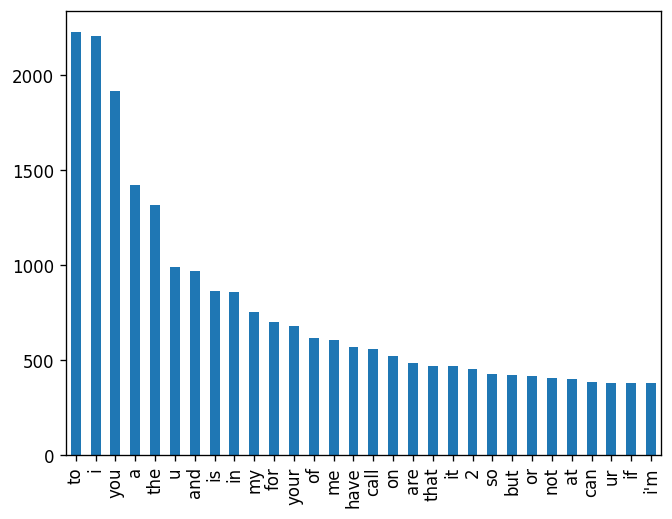

In [20]:
raw=' '.join(data['message'].str.lower().values)
raw_word_count_series=pd.Series(raw.split()).value_counts()
plt.figure(dpi=120)
raw_word_count_series[:30].plot(kind='bar')
plt.show()

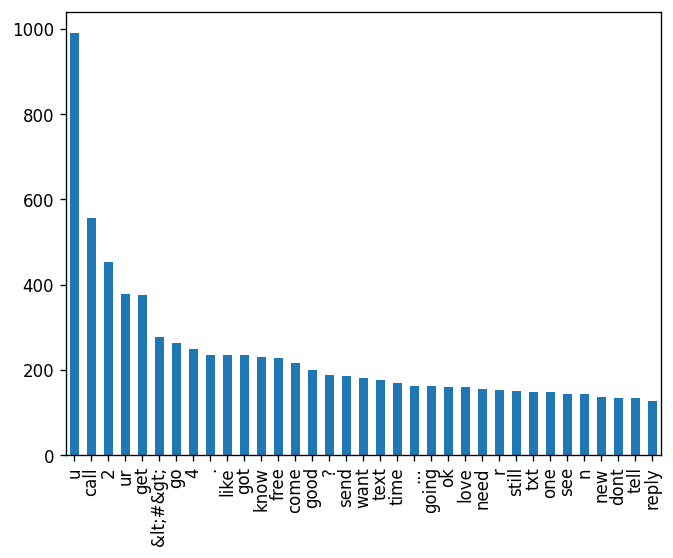

In [21]:
plt.figure(dpi=120)
word_count_series[:35].plot(kind='bar')
plt.show()

In [22]:
import string

In [23]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [24]:
string.digits

'0123456789'

In [25]:
string.ascii_letters

'abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ'

In [26]:
ls=['u', '2', 'ur', '4', '.', '...', "i'm", 'n', 'r']+ list(string.punctuation)
print(ls)

['u', '2', 'ur', '4', '.', '...', "i'm", 'n', 'r', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', ':', ';', '<', '=', '>', '?', '@', '[', '\\', ']', '^', '_', '`', '{', '|', '}', '~']


In [27]:
stopword

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [28]:
len(stopword)

198

In [29]:
stopword+=ls

In [30]:
stopword

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [31]:
len(stopword)

239

In [32]:
s=process_text(corpus)
s

'go jurong point, crazy.. available bugis great world la e buffet... cine got amore wat... ok lar... joking wif oni... free entry wkly comp win fa cup final tkts 21st may 2005. text fa 87121 receive entry question(std txt rate)t&c\'s apply 08452810075over18\'s dun say early hor... c already say... nah think goes usf, lives around though freemsg hey darling 3 week\'s word back! like fun still? tb ok! xxx std chgs send, å£1.50 rcv even brother like speak me. treat like aids patent. per request \'melle melle (oru minnaminunginte nurungu vettam)\' set callertune callers. press *9 copy friends callertune winner!! valued network customer selected receivea å£900 prize reward! claim call 09061701461. claim code kl341. valid 12 hours only. mobile 11 months more? entitled update latest colour mobiles camera free! call mobile update co free 08002986030 gonna home soon want talk stuff anymore tonight, k? cried enough today. six chances win cash! 100 20,000 pounds txt> csh11 send 87575. cost 150p/d

In [33]:
series=pd.Series(s.split()).value_counts()

In [34]:
series

call          557
get           375
&lt;#&gt;     276
go            262
got           234
             ... 
\yeh            1
curtsey?        1
practising      1
tool!           1
rofl.           1
Name: count, Length: 13303, dtype: int64

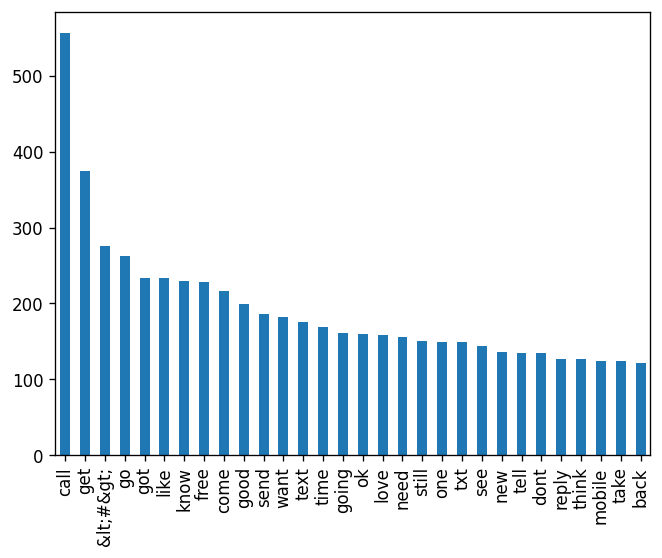

In [35]:
plt.figure(dpi=120)
series[:30].plot(kind='bar')
plt.show()

### Regex - for pattern matching ?

In [36]:
data

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [37]:
data.groupby('label').groups

{'ham': [0, 1, 3, 4, 6, 7, 10, 13, 14, 16, 17, 18, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 35, 36, 37, 38, 39, 40, 41, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 55, 57, 58, 59, 60, 61, 62, 63, 64, 66, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 94, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 114, 115, 117, 118, ...], 'spam': [2, 5, 8, 9, 11, 12, 15, 19, 34, 42, 54, 56, 65, 67, 68, 93, 95, 113, 116, 119, 120, 122, 133, 134, 138, 146, 158, 159, 163, 164, 166, 187, 190, 224, 226, 234, 239, 249, 258, 263, 267, 269, 272, 295, 304, 308, 311, 318, 332, 334, 348, 356, 357, 366, 367, 374, 384, 388, 400, 414, 417, 419, 421, 423, 432, 454, 462, 470, 473, 486, 491, 504, 514, 516, 517, 524, 526, 528, 530, 540, 563, 575, 578, 582, 590, 591, 592, 597, 606, 610, 628, 629, 634, 647, 649, 659, 671, 672, 683, 689, ...]}

In [38]:
ham=data.iloc[data.groupby('label').groups['ham']]
spam=data.iloc[data.groupby('label').groups['spam']]

In [39]:
ham

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
6,ham,Even my brother is not like to speak with me. ...
...,...,...
5565,ham,Huh y lei...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [40]:
spam

,label,message
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
5,spam,FreeMsg Hey there darling it's been 3 week's n...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...
11,spam,"SIX chances to win CASH! From 100 to 20,000 po..."
...,...,...
5537,spam,Want explicit SEX in 30 secs? Ring 02073162414...
5540,spam,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547,spam,Had your contract mobile 11 Mnths? Latest Moto...
5566,spam,REMINDER FROM O2: To get 2.50 pounds free call...


In [41]:
ham_series=pd.Series([word for doc in ham['message'].values for word in doc.split()]).value_counts()
spam_series=pd.Series([word for doc in spam['message'].values for word in doc.split()]).value_counts()

In [42]:
ham_series

to          1530
you         1458
I           1436
the         1019
a            969
            ... 
basket's       1
dane           1
corrct         1
S..antha       1
Rofl.          1
Name: count, Length: 12479, dtype: int64

In [43]:
spam_series

to        604
a         358
your      187
or        185
call      185
         ... 
80488.      1
31          1
PHP         1
Where       1
NOW1!       1
Name: count, Length: 4312, dtype: int64

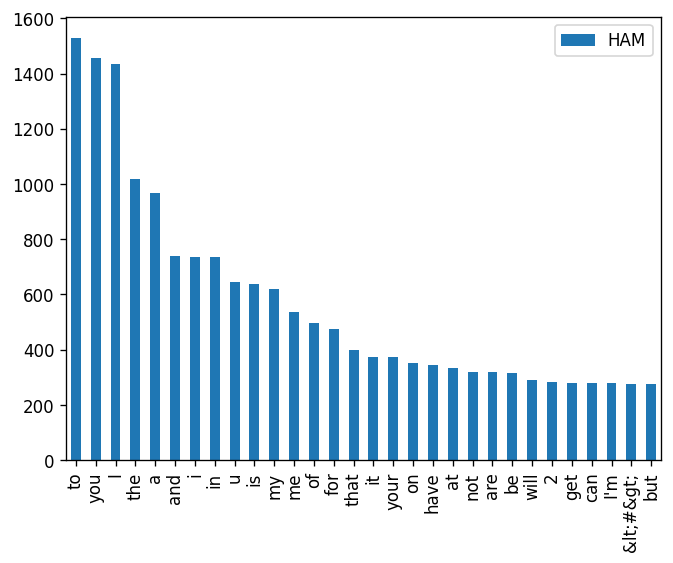

In [44]:
plt.figure(dpi=120)
ham_series[:30].plot(kind='bar', label='HAM')
plt.legend()
plt.show()

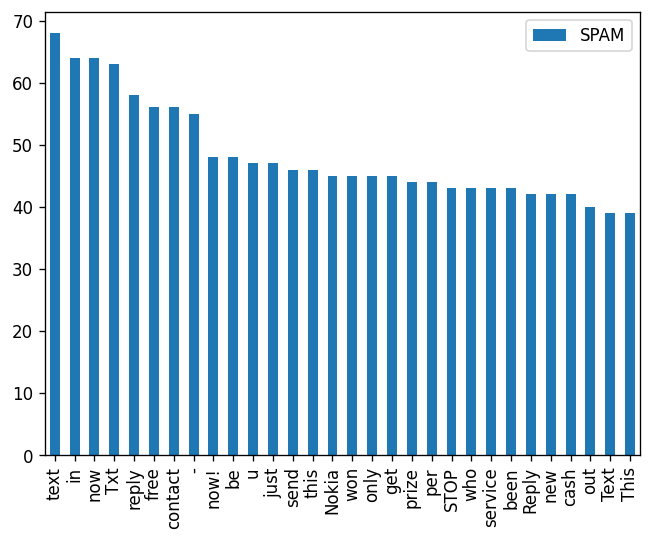

In [45]:
plt.figure(dpi=120)
spam_series[30:60].plot(kind='bar', label='SPAM')
plt.legend()
plt.show()

    - what is the average length of spam or ham message ?
    - what is the average word count of spam or ham message ?

In [46]:
def process_text(text): 
    msg=text.lower()
    sentance=[]
    for word in msg.split(): 
        if word not in stopword: 
            sentance.append(word)
    msg=" ".join(sentance)
    return msg

In [47]:
spam

,label,message
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
5,spam,FreeMsg Hey there darling it's been 3 week's n...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...
11,spam,"SIX chances to win CASH! From 100 to 20,000 po..."
...,...,...
5537,spam,Want explicit SEX in 30 secs? Ring 02073162414...
5540,spam,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547,spam,Had your contract mobile 11 Mnths? Latest Moto...
5566,spam,REMINDER FROM O2: To get 2.50 pounds free call...


In [48]:
spam['message']=spam.message.apply(process_text)

C:\Users\DELL\AppData\Local\Temp\ipykernel_11556\995374444.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spam['message']=spam.message.apply(process_text)


In [49]:
spam

,label,message
2,spam,free entry wkly comp win fa cup final tkts 21s...
5,spam,freemsg hey darling 3 week's word back! like f...
8,spam,winner!! valued network customer selected rece...
9,spam,mobile 11 months more? entitled update latest ...
11,spam,"six chances win cash! 100 20,000 pounds txt> c..."
...,...,...
5537,spam,want explicit sex 30 secs? ring 02073162414 no...
5540,spam,asked 3mobile 0870 chatlines inclu free mins. ...
5547,spam,"contract mobile 11 mnths? latest motorola, nok..."
5566,spam,reminder o2: get 2.50 pounds free call credit ...


In [50]:
ham['message']=ham.message.apply(process_text)

C:\Users\DELL\AppData\Local\Temp\ipykernel_11556\3369501246.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ham['message']=ham.message.apply(process_text)


In [51]:
ham

,label,message
0,ham,"go jurong point, crazy.. available bugis great..."
1,ham,ok lar... joking wif oni...
3,ham,dun say early hor... c already say...
4,ham,"nah think goes usf, lives around though"
6,ham,even brother like speak me. treat like aids pa...
...,...,...
5565,ham,huh lei...
5568,ham,ì_ b going esplanade fr home?
5569,ham,"pity, mood that. so...any suggestions?"
5570,ham,guy bitching acted like interested buying some...


In [52]:
avg_len_ham=np.mean([len(i) for i in ham.message.values])
avg_len_spam=np.mean([len(i) for i in spam.message.values])

In [53]:
avg_len_ham

48.707564766839376

In [54]:
avg_len_spam

112.51673360107095

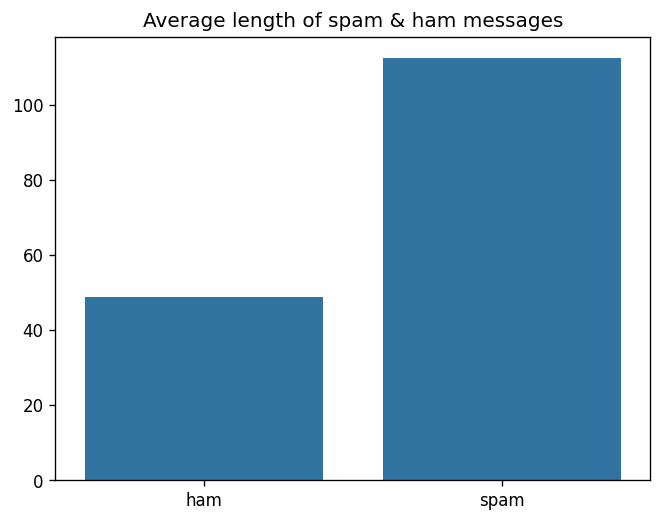

In [55]:
plt.figure(dpi=120)
sns.barplot(x=['ham', 'spam'], y=[avg_len_ham, avg_len_spam])
plt.title("Average length of spam & ham messages")
plt.show()

In [56]:
avg_word_count_ham=np.mean([len(i.split()) for i in ham.message.values]) 
avg_word_count_spam=np.mean([len(i.split()) for i in spam.message.values]) 

In [57]:
avg_word_count_ham

8.018238341968912

In [58]:
avg_word_count_spam

16.400267737617135

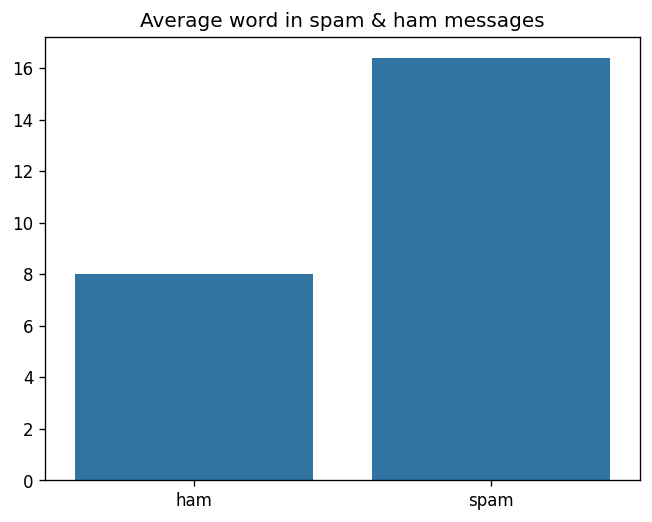

In [59]:
plt.figure(dpi=120)
sns.barplot(x=['ham', 'spam'], y=[avg_word_count_ham, avg_word_count_spam])
plt.title("Average word in spam & ham messages")
plt.show()

# Word Cloud 

In [60]:
from wordcloud import WordCloud

In [61]:
s="hello everyone hi hello python is awesome awesome hello python python"

In [62]:
wc=WordCloud(background_color='white', width=600, height=700)

In [63]:
wc.generate_from_text(s)

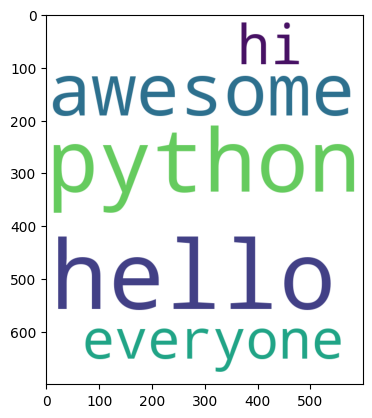

In [64]:
plt.imshow(wc.generate_from_text(s))

In [65]:
spam_string=' '.join(spam.message.values)
spam_string

'free entry wkly comp win fa cup final tkts 21st may 2005. text fa 87121 receive entry question(std txt rate)t&c\'s apply 08452810075over18\'s freemsg hey darling 3 week\'s word back! like fun still? tb ok! xxx std chgs send, å£1.50 rcv winner!! valued network customer selected receivea å£900 prize reward! claim call 09061701461. claim code kl341. valid 12 hours only. mobile 11 months more? entitled update latest colour mobiles camera free! call mobile update co free 08002986030 six chances win cash! 100 20,000 pounds txt> csh11 send 87575. cost 150p/day, 6days, 16+ tsandcs apply reply hl info urgent! 1 week free membership å£100,000 prize jackpot! txt word: claim no: 81010 t&c www.dbuk.net lccltd pobox 4403ldnw1a7rw18 xxxmobilemovieclub: use credit, click wap link next txt message click here>> http://wap. xxxmobilemovieclub.com?n=qjkgighjjgcbl england v macedonia dont miss goals/team news. txt national team 87077 eg england 87077 try:wales, scotland 4txt/ì¼1.20 poboxox36504w45wq 16+ t

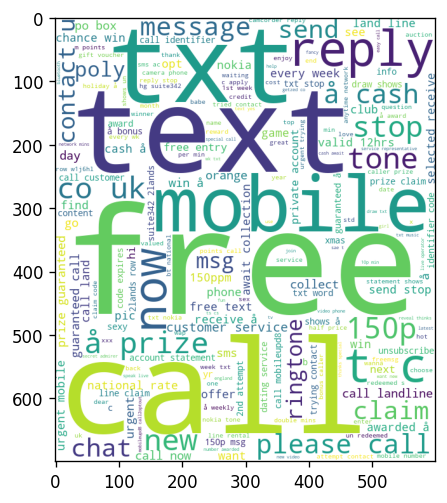

In [66]:
plt.figure(dpi=120)
wc=WordCloud(background_color='white', width=600, height=700)
plt.imshow(wc.generate_from_text(spam_string))

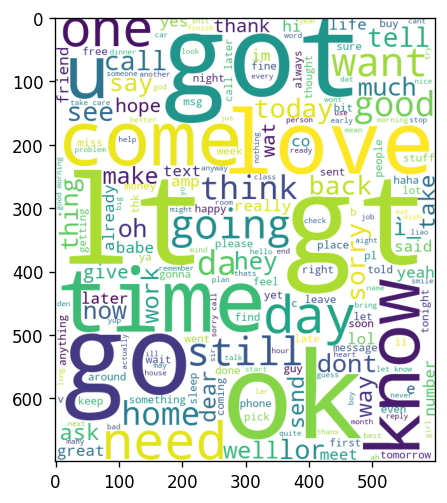

In [67]:
ham_string=' '.join(ham.message.values)

plt.figure(dpi=120)
wc=WordCloud(background_color='white', width=600, height=700)
plt.imshow(wc.generate_from_text(ham_string))

# Stemming & Lemmetization

        - Convert word to its root form 

        - Stem means root

        - 1. Porter Stemmer -> It is old technique (Stripping suffix from text)
          2. Lanchaster Stemmer -> 
          3. Snowball Stemmer -> It is used for non english languages.

        - Eg. flying -> fly 
              flyer -> fly

In [68]:
from nltk import PorterStemmer
from nltk import LancasterStemmer
from nltk import SnowballStemmer

In [69]:
porter=PorterStemmer()

In [70]:
porter.stem('flying')

'fli'

In [71]:
porter.stem('dogs')

'dog'

In [72]:
porter.stem('asking')

'ask'

In [73]:
[porter.stem(i) for i in ['fly','flying','flew']]

['fli', 'fli', 'flew']

In [74]:
lancaster=LancasterStemmer()

In [75]:
lancaster.stem('flying')

'fly'

In [76]:
[lancaster.stem(i) for i in ['fly','flying','flew']]

['fly', 'fly', 'flew']

In [77]:
import nltk 
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [78]:
from nltk.stem import WordNetLemmatizer

In [79]:
lemma=WordNetLemmatizer()

In [80]:
lemma.lemmatize('flying')         # according to noun which is default

'flying'

In [81]:
lemma.lemmatize('flying','v')       # according to verb

'fly'

In [82]:
lemma.lemmatize('dogs')

'dog'

# TF(Term Frequency)

    t = "hello"
    
    d1 = "hello let's go somewhere hello"    # tf = 2 / 5    importance of term in document
    
    d2 = "hello hii hello bye hello"         # tf = 3 / 5
    
    d3 = "hello we are learning python"      # tf = 1 / 5

    d4 = "bye bye bye bye"                   # tf = 0 / 5 = 0

    d5 = "go bye bye let's go"               # tf = 0 / 5 = 0

# DF(Document Frequency)

    3 / 5 ---> df    

# IDF(Inverse Document Frequency)

    IDF = N / DF

    DF = 0
    IDF = infinite 

    IDF = N / DF + 1

    N=1000
    DF = 0

    IDF = 1000   here we get high value of IDF

    So, =>  IDF = log(N / DF + 1)

In [83]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [84]:
tfidf = TfidfVectorizer()

In [85]:
tfidf

TfidfVectorizer()

In [86]:
data= ["hello how are you?", "hello bye bye", "yeah yes why no"]

In [87]:
tfidf.fit_transform(data)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 10 stored elements and shape (3, 9)>

In [88]:
tfidf.fit_transform(data).toarray()

array([[0.52863461, 0.        , 0.40204024, 0.52863461, 0.        ,
        0.        , 0.        , 0.        , 0.52863461],
       [0.        , 0.93470196, 0.35543247, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.5       ,
        0.5       , 0.5       , 0.5       , 0.        ]])

In [89]:
count_vector = CountVectorizer()
count_vector.fit_transform(data).toarray()

array([[1, 0, 1, 1, 0, 0, 0, 0, 1],
       [0, 2, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 1, 1, 1, 0]], dtype=int64)